# Phase 4: Evaluation & Forecasting

**Objective:**
Final evaluation of the SARIMA models. In this separate notebook, we will:
1. Load the prepared daily data.
2. Initialize the specific SARIMA models defined in Phase 3.
3. Forecast the "hidden" test years (2005 and 2017).
4. Calculate accuracy metrics (MAE, RMSE, MAPE) and visually compare predictions.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")
pjme_daily = pd.read_csv('pjme_daily_cleaned.csv', index_col=0, parse_dates=True)
pjme_daily.index.freq = 'D'


### 1. Model Initialization
We re-initialize the SARIMA models using the optimal parameters determined in Phase 3.
* **Early Era (Training: 2002-2004):** SARIMA(3, 0, 0)x(2, 0, 1, 7)
* **Late Era (Training: 2014-2016):** SARIMA(2, 0, 2)x(2, 0, 1, 7)

In [15]:
# 1. Early Era Model (2002-2004)
train_early = pjme_daily.loc['2002':'2004']['PJME']
model_early = SARIMAX(train_early, order=(3, 0, 0), seasonal_order=(2, 0, 1, 7))
results_early = model_early.fit(disp=False)

# 2. Late Era Model (2014-2016)
train_late = pjme_daily.loc['2014':'2016']['PJME']
model_late = SARIMAX(train_late, order=(2, 0, 2), seasonal_order=(2, 0, 1, 7))
results_late = model_late.fit(disp=False)

### 2. Forecasting & Metrics
We generate forecasts for the test years (2005 and 2017) and compare them against the actual observed values using three metrics:
* **MAE:** Mean Absolute Error (Average error in MW).
* **RMSE:** Root Mean Square Error (Penalizes large errors).
* **MAPE:** Mean Absolute Percentage Error (Relative accuracy).

In [18]:
# Forecast for test years
pred_2005 = results_early.predict(start='2005-01-01', end='2005-12-31')
pred_2017 = results_late.predict(start='2017-01-01', end='2017-12-31')

# Actual values
actual_2005 = pjme_daily.loc['2005']['PJME']
actual_2017 = pjme_daily.loc['2017']['PJME']

mae_05 = mean_absolute_error(actual_2005, pred_2005)
rmse_05 = np.sqrt(mean_squared_error(actual_2005, pred_2005))
mape_05 = np.mean(np.abs((actual_2005 - pred_2005) / actual_2005)) * 100

mae_17 = mean_absolute_error(actual_2017, pred_2017)
rmse_17 = np.sqrt(mean_squared_error(actual_2017, pred_2017))
mape_17 = np.mean(np.abs((actual_2017 - pred_2017) / actual_2017)) * 100

print("--- Results for Early Era (2005) ---")
print(f"MAE:  {mae_05:.2f}")
print(f"RMSE: {rmse_05:.2f}")
print(f"MAPE: {mape_05:.2f}%")
print("\n--- Results for Late Era (2017) ---")
print(f"MAE:  {mae_17:.2f}")
print(f"RMSE: {rmse_17:.2f}")
print(f"MAPE: {mape_17:.2f}%")

--- Results for Early Era (2005) ---
MAE:  4602.57
RMSE: 6211.03
MAPE: 12.51%

--- Results for Late Era (2017) ---
MAE:  3536.09
RMSE: 4470.11
MAPE: 11.12%


### 3. Visual Comparison
The plots below display the Actual Data (Blue) versus the Forecasted values (Red). This allows visual verification of whether the model captures the weekly seasonality and peak demands.

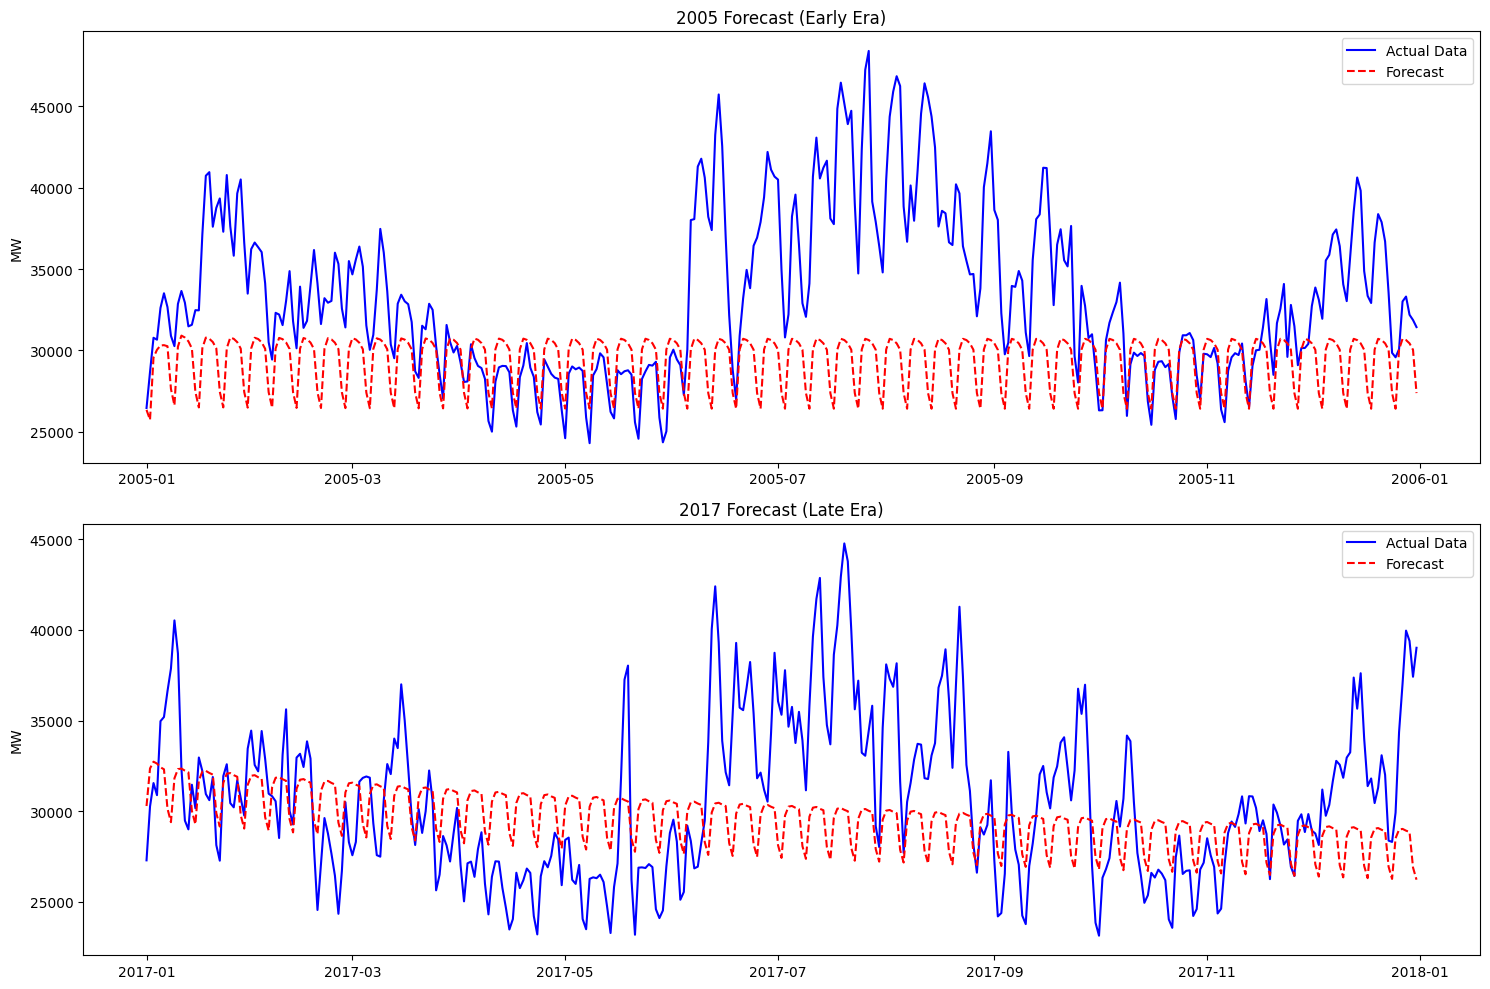

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 2005
axes[0].plot(actual_2005.index, actual_2005, label='Actual Data', color='blue')
axes[0].plot(pred_2005.index, pred_2005, label='Forecast', color='red', linestyle='--')
axes[0].set_title('2005 Forecast (Early Era)')
axes[0].set_ylabel('MW')
axes[0].legend()

# Plot 2017
axes[1].plot(actual_2017.index, actual_2017, label='Actual Data', color='blue')
axes[1].plot(pred_2017.index, pred_2017, label='Forecast', color='red', linestyle='--')
axes[1].set_title('2017 Forecast (Late Era)')
axes[1].set_ylabel('MW')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Conclusion

**Era Comparison:**
* **Early Era (2005):** MAPE = **12.51%**
* **Late Era (2017):** MAPE = **11.12%**

**Verdict:**
The model performed better in the **Late Era (2017)**. This indicates that the specific SARIMA parameters tuned for the modern period were able to capture the consumption patterns slightly more accurately than the model for the early 2000s.

**Model Robustness:**
The visual analysis confirms that the model successfully captures the **weekly seasonality** (regular peaks and valleys). However, the model tends to **underestimate extreme peaks** (outliers) during high-demand summer and winter days. This is a typical limitation of SARIMA, which focuses on average trends rather than temperature-driven extremes.